# Part 0 - Intro

This notebook takes a lot of inspiration from:
- https://www.kaggle.com/keegil/keras-u-net-starter-lb-0-277
- https://www.kaggle.com/weiji14/yet-another-keras-u-net-data-augmentation
- and many others!

I added the visualization of the input and result images. 

To simplify the problem, all the individual nuclei masks of an  input  image are merged to one flatten mask image. I just evaluate whether a pixel is marked as nuclei or not correctly.

In [1]:
# Set number of GPUs
num_gpus = 1   #defaults to 1 if one-GPU or one-CPU. If 4 GPUs, set to 4.

# Set height (y-axis length) and width (x-axis length) to train model on
img_height, img_width = (256,256)  #Default to (256,266), use (None,None) if you do not want to resize imgs

In [2]:
# Import all the necessary libraries
import os
import datetime
import glob
import random
import sys

import matplotlib.pyplot as plt
import skimage.io                                     #Used for imshow function
import skimage.transform                              #Used for resize function
from skimage.morphology import label                  #Used for Run-Length-Encoding RLE to create final submission

import numpy as np
import pandas as pd

import keras
from keras.layers import Input, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, Conv2DTranspose
from keras.layers import AveragePooling2D, MaxPooling2D, Dropout, GlobalMaxPooling2D, GlobalAveragePooling2D, Lambda
from keras.layers.advanced_activations import LeakyReLU
from keras.models import load_model, Model
from keras.preprocessing.image import ImageDataGenerator
from keras.layers.merge import add, concatenate
from keras.callbacks import EarlyStopping, ModelCheckpoint
#from keras.utils import plot_model#multi_gpu_model, plot_model
from keras.utils.vis_utils import plot_model
from tensorflow.python.keras.utils.multi_gpu_utils import multi_gpu_model
#from keras import backend as K
#from tensorflow.keras import backend as K
#import tensorflow.keras.backend as K
#import tensorflow.compat.v1.keras.backend as K
#import tensorflow.python.keras.backend as K
#from tensorflow.python.keras.backend import get_session
#from tensorflow.python.keras.backend import get_session as K


import tensorflow as tf
tf.compat.v1.disable_eager_execution()
sess = tf.compat.v1.keras.backend.get_session()
import tensorflow.compat.v1.keras.backend as K

import sklearn
from sklearn.model_selection import train_test_split


print('Python       :', sys.version.split('\n')[0])
print('Numpy        :', np.__version__)
print('Skimage      :', skimage.__version__)
print('Scikit-learn :', sklearn.__version__)
print('Keras        :', keras.__version__)
print('Tensorflow   :', tf.__version__)

Python       : 3.7.13 (default, Apr 24 2022, 01:04:09) 
Numpy        : 1.21.6
Skimage      : 0.18.3
Scikit-learn : 1.0.2
Keras        : 2.8.0
Tensorflow   : 2.8.0


In [3]:
# Set seed values
seed = 42
random.seed = seed
np.random.seed(seed=seed)

In [4]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
topDir = "/content/gdrive/My Drive/Colab Notebooks/paper_two_detect_segment/images_electric_parts_drone"
#os.listdir(root_dir)

Mounted at /content/gdrive


In [5]:
# Have a look at our data folder
#topDir = '/home/triscillar/Documents/projects/PhD_mini_projects/paper_two_detect_segment/images_electric_parts_drone' #defaults to '/kaggle' in kaggle kernels, different if on own system e.g. '/home/user/kaggle/dsbowl'
os.chdir(topDir)    #changes our python working directory to the top directory of our kaggle files
print(os.listdir(os.path.join(topDir, 'input')))  #see what's in the input folder (where data is in)

['test_split', 'train_split']


In [6]:
train_path = os.path.join(topDir, 'input/train_split')  #path to training data file/folder
test_path = os.path.join(topDir, 'input/test_split')   #path to test data file/folder

In [7]:
# Get train and test IDs
train_ids = next(os.walk(train_path))[1]
test_ids = next(os.walk(test_path))[1]

# Part 1 - Data Input

In [8]:
%%time
# Get training data
def get_X_data(path, output_shape=(None, None)):
    '''
    Loads images from path/{id}/images/{id}.png into a numpy array
    '''
    img_paths = ['{0}/{1}/images/{1}.png'.format(path, id) for id in os.listdir(path)]
    X_data = np.array([skimage.transform.resize(skimage.io.imread(path)[:,:,:3], output_shape=output_shape, mode='constant', preserve_range=True) for path in img_paths], dtype=np.uint8)  #take only 3 channels/bands
    
    return X_data


CPU times: user 0 ns, sys: 5 µs, total: 5 µs
Wall time: 10.5 µs


In [9]:
X_train = get_X_data(train_path, output_shape=(img_height,img_width))
print(X_train.shape, X_train.dtype)

(360, 256, 256, 3) uint8


In [10]:
X_test = get_X_data(test_path, output_shape=(img_height,img_width))
print(X_test.shape, X_test.dtype)

(87, 256, 256, 3) uint8


In [11]:
%%time
# Get training data labels
def get_Y_data(path, output_shape=(None, None)):
    '''
    Loads and concatenates images from path/{id}/masks/{id}.png into a numpy array
    '''
    img_paths = [glob.glob('{0}/{1}/masks/*.png'.format(path, id)) for id in os.listdir(path)]
    
    Y_data = []
    for i, img_masks in enumerate(img_paths):  #loop through each individual nuclei for an image and combine them together
        masks = skimage.io.imread_collection(img_masks).concatenate()  #masks.shape = (num_masks, img_height, img_width)
        mask = np.max(masks, axis=0)                                   #mask.shape = (img_height, img_width)
        mask = skimage.transform.resize(mask, output_shape=output_shape+(1,), mode='constant', preserve_range=True)  #need to add an extra dimension so mask.shape = (img_height, img_width, 1)
        Y_data.append(mask)
    Y_data = np.array(Y_data, dtype=np.bool_)
    
    return Y_data


CPU times: user 4 µs, sys: 5 µs, total: 9 µs
Wall time: 9.54 µs


In [12]:
Y_train = get_Y_data(train_path, output_shape=(img_height,img_width))
print(Y_train.shape, Y_train.dtype)

(360, 256, 256, 1) bool


In [13]:
Y_test = get_Y_data(test_path, output_shape=(img_height,img_width))
print(Y_test.shape, Y_test.dtype)

(87, 256, 256, 1) bool


## Visualize masks on the training data

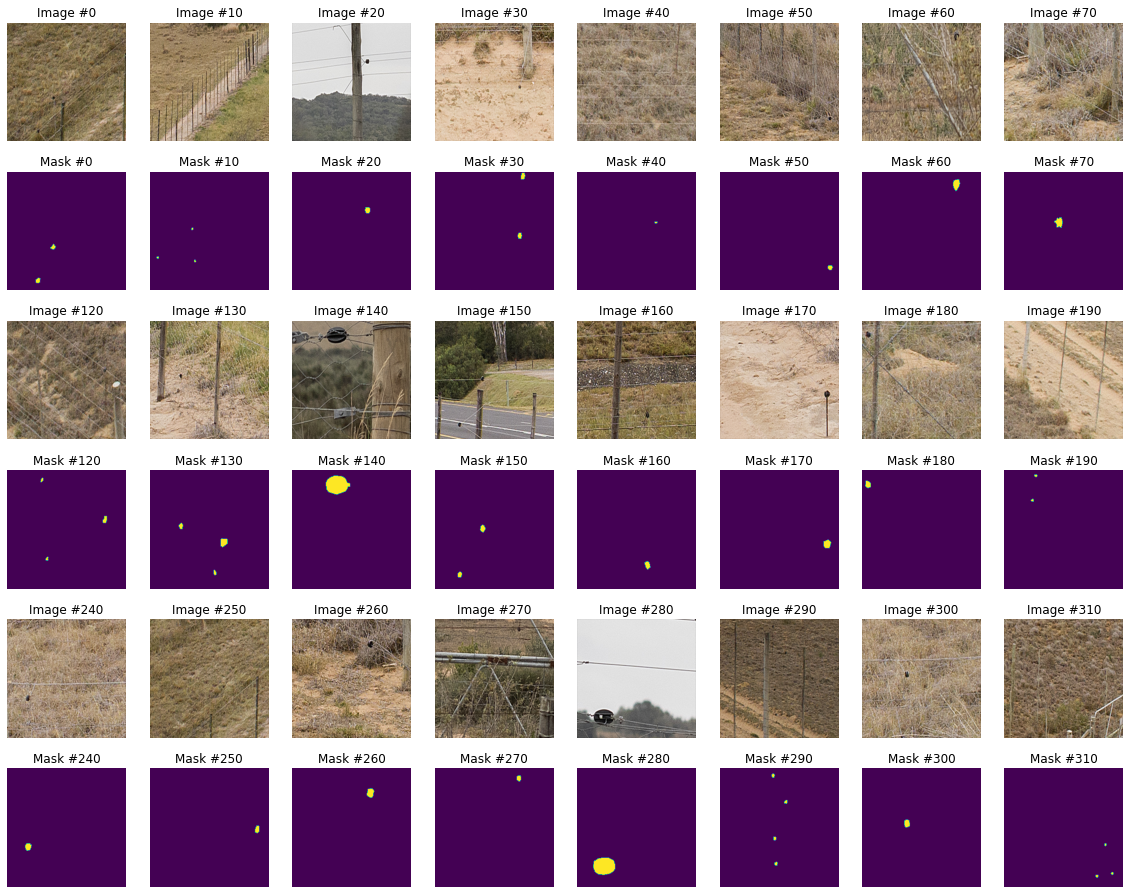

In [14]:
# Illustrate the train images and masks
plt.figure(figsize=(20,16))
x, y = 8,3
for i in range(y):  
    for j in range(x):
        # train image
        plt.subplot(y*2, x, i*2*x+j+1)
        pos = i*120 + j*10
        plt.imshow(X_train[pos])
        plt.title('Image #{}'.format(pos))
        plt.axis('off')
        plt.subplot(y*2, x, (i*2+1)*x+j+1)
        plt.imshow(np.squeeze(Y_train[pos]))
        plt.title('Mask #{}'.format(pos))
        plt.axis('off')
#plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

# Part 2 - Build model

In [15]:
def keras_model(img_width=256,img_height=256,IMG_CHANNELS=3):
    inputs = Input((img_height, img_width, IMG_CHANNELS))
    s = Lambda(lambda x: x / 255) (inputs)
    c1 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (s)
    c1 = Dropout(0.1) (c1)
    c1 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c1)
    p1 = MaxPooling2D((2, 2)) (c1)
    c2 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p1)
    c2 = Dropout(0.1) (c2)
    c2 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c2)
    p2 = MaxPooling2D((2, 2)) (c2)

    c3 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p2)
    c3 = Dropout(0.2) (c3)
    c3 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c3)
    p3 = MaxPooling2D((2, 2)) (c3)

    c4 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p3)
    c4 = Dropout(0.2) (c4)
    c4 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c4)
    p4 = MaxPooling2D(pool_size=(2, 2)) (c4)

    c5 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p4)
    c5 = Dropout(0.3) (c5)
    c5 = Conv2D(256, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c5)

    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same') (c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u6)
    c6 = Dropout(0.2) (c6)
    c6 = Conv2D(128, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c6)

    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same') (c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u7)
    c7 = Dropout(0.2) (c7)
    c7 = Conv2D(64, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c7)

    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same') (c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u8)
    c8 = Dropout(0.1) (c8)
    c8 = Conv2D(32, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c8)

    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same') (c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (u9)
    c9 = Dropout(0.1) (c9)
    c9 = Conv2D(16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid') (c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    #model.compile(optimizer='adam',loss='binary_crossentropy', metrics=[iou_coef])
    return model

In [16]:
# Custom IoU metric
def mean_iou(y_true, y_pred):
    prec = []
    for t in np.arange(0.5, 1.0, 0.05):
        #y_pred_ = tf.to_int32(y_pred > t)
        y_pred_ = tf.cast(y_pred > t, dtype = tf.int32)
        score, up_opt = tf.compat.v1.metrics.mean_iou(y_true, y_pred_, 2)
        #score, up_opt = tf.metrics.mean_iou(y_true, y_pred_, 2)
        sess.run(tf.compat.v1.local_variables_initializer())
        with tf.control_dependencies([up_opt]):
            score = tf.identity(score)
        prec.append(score)
    return K.mean(K.stack(prec), axis=0)

# Custom loss function
def dice_coef(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def bce_dice_loss(y_true, y_pred):
    return 0.5 * keras.losses.binary_crossentropy(y_true, y_pred) - dice_coef(y_true, y_pred)

In [17]:
# Set some model compile parameters
optimizer = 'adam'
loss      = bce_dice_loss
metrics   = [mean_iou]

# Compile our model
model = keras_model(img_width=img_width, img_height=img_height)
model.summary()

# For more GPUs
if num_gpus > 1:
    model = multi_gpu_model(model, gpus=num_gpus)

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 lambda (Lambda)                (None, 256, 256, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 16  448         ['lambda[0][0]']                 
                                )                                                                 
                                                                                              

# Part 3 - Run model

In [18]:
# Runtime data augmentation
def get_train_test_augmented(X_data=X_train, Y_data=Y_train, validation_split=0.1, batch_size=32, seed=seed):
    X_train, X_test, Y_train, Y_test = train_test_split(X_data,
                                                        Y_data,
                                                        train_size=1-validation_split,
                                                        test_size=validation_split,
                                                        random_state=seed)
    # Image data generator distortion options
    data_gen_args = dict(rotation_range=45.,
                     width_shift_range=0.1,
                     height_shift_range=0.1,
                     shear_range=0.2,
                     zoom_range=0.2,
                     horizontal_flip=True,
                     vertical_flip=True,
                     fill_mode='reflect') #use 'constant'??
    

    # Train data, provide the same seed and keyword arguments to the fit and flow methods
    X_datagen = ImageDataGenerator(**data_gen_args)
    Y_datagen = ImageDataGenerator(**data_gen_args)
    X_datagen.fit(X_train, augment=True, seed=seed)
    Y_datagen.fit(Y_train, augment=True, seed=seed)
    X_train_augmented = X_datagen.flow(X_train, batch_size=batch_size, shuffle=True, seed=seed)
    Y_train_augmented = Y_datagen.flow(Y_train, batch_size=batch_size, shuffle=True, seed=seed)
     
    
    # Test data, no data augmentation, but we create a generator anyway
    X_datagen_val = ImageDataGenerator()
    Y_datagen_val = ImageDataGenerator()
    X_datagen_val.fit(X_test, augment=True, seed=seed)
    Y_datagen_val.fit(Y_test, augment=True, seed=seed)
    X_test_augmented = X_datagen_val.flow(X_test, batch_size=batch_size, shuffle=True, seed=seed)
    Y_test_augmented = Y_datagen_val.flow(Y_test, batch_size=batch_size, shuffle=True, seed=seed)
    
    
    # combine generators into one which yields image and masks
    train_generator = zip(X_train_augmented, Y_train_augmented)
    test_generator = zip(X_test_augmented, Y_test_augmented)
    
    return train_generator, test_generator, X_train, X_test, Y_train, Y_test

In [19]:
# Runtime custom callbacks
#%% https://github.com/deepsense-ai/intel-ai-webinar-neural-networks/blob/master/live_loss_plot.py
# Fixed code to enable non-flat loss plots on keras model.fit_generator()
import matplotlib.pyplot as plt
from keras.callbacks import Callback
from IPython.display import clear_output
#from matplotlib.ticker import FormatStrFormatter

def translate_metric(x):
    translations = {'acc': "Accuracy", 'loss': "Log-loss (cost function)"}
    if x in translations:
        return translations[x]
    else:
        return x

class PlotLosses(Callback):
    def __init__(self, figsize=None):
        super(PlotLosses, self).__init__()
        self.figsize = figsize

    def on_train_begin(self, logs={}):

        self.base_metrics = [metric for metric in self.params['metrics'] if not metric.startswith('val_')]
        self.logs = []

    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(logs.copy())

        clear_output(wait=True)
        plt.figure(figsize=self.figsize)
        
        for metric_id, metric in enumerate(self.base_metrics):
            plt.subplot(1, len(self.base_metrics), metric_id + 1)
            
            plt.plot(range(1, len(self.logs) + 1),
                     [log[metric] for log in self.logs],
                     label="training")
            if self.params['do_validation']:
                plt.plot(range(1, len(self.logs) + 1),
                         [log['val_' + metric] for log in self.logs],
                         label="validation")
            plt.title(translate_metric(metric))
            plt.xlabel('epoch')
            plt.legend(loc='center left')
        
        plt.tight_layout()
        plt.show();

plot_losses = PlotLosses(figsize=(8, 3))

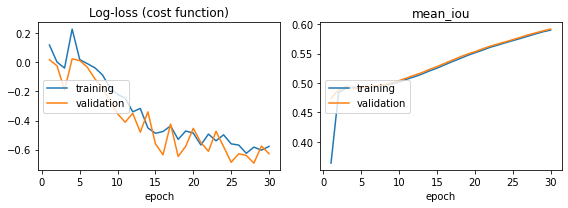

10/10 [==============================] - 232s 24s/step - batch: 5.0000 - size: 16.0000 - loss: -0.5781 - mean_iou: 0.5900 - val_loss: -0.6288 - val_mean_iou: 0.5917


In [ ]:
# Finally train the model!!
batch_size = 16
early_stop = EarlyStopping(monitor='loss',patience=20, restore_best_weights=True)

train_generator, test_generator, X_train, X_val, Y_train, Y_val = get_train_test_augmented(X_data=X_train, Y_data=Y_train, validation_split=0.1, batch_size=batch_size)

# increase epoch on your own machine
history = model.fit(train_generator, validation_data=test_generator, validation_steps=batch_size/2, steps_per_epoch=len(X_train)/(batch_size*2), epochs=30, callbacks=[plot_losses])

In [ ]:
# Save the model weights to a hdf5 file
if num_gpus > 1:
    #Refer to https://stackoverflow.com/questions/41342098/keras-load-checkpoint-weights-hdf5-generated-by-multiple-gpus
    #model.summary()
    model_out = model.layers[-2]  #get second last layer in multi_gpu_model i.e. model.get_layer('model_1')
else:
    model_out = model
model_out.save_weights("model-weights.hdf5")

Text(0.5, 1.0, 'Loss and accuracy curves for aerial images baseline_cnn_detect model')

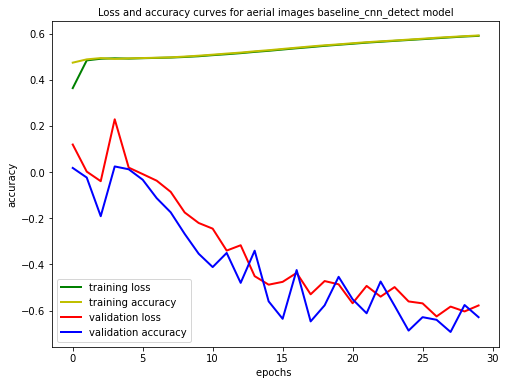

In [ ]:
#Plot the Graph

# Loss Curves

plt.figure(figsize=[8,6])
plt.plot(history.history['mean_iou'],'g',label='accuracy',linewidth=2.0)
plt.plot(history.history['val_mean_iou'],'y',label='val_accuracy',linewidth=2.0)
plt.plot(history.history['loss'],'r',label='loss',linewidth=2.0)
plt.plot(history.history['val_loss'],'b',label='val_loss',linewidth=2.0)
plt.legend(['training loss','training accuracy', 'validation loss', 'validation accuracy'],fontsize=10)
plt.xlabel('epochs ',fontsize=10)
plt.ylabel('accuracy',fontsize=10)
plt.title('Loss and accuracy curves for aerial images baseline_cnn_detect model',fontsize=10)
#plt.savefig('loss_acc_curves_baseline.png')

# Part 4 - Evaluate output

## Visualize predictions on the validation data

In [ ]:
# Reload the model
model_loaded = keras_model(img_width=img_width, img_height=img_height)
model_loaded.load_weights("model-weights.hdf5")

In [ ]:
# Predict on val
preds_val = model.predict(X_val, verbose=1)
# Threshold predictions
#preds_val_t = (preds_val > 0.5).astype(np.uint8)
preds_val_t = (preds_val > 0.5)

/usr/local/lib/python3.7/dist-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


In [ ]:
# Define IoU metric as a regular function, to manually check result
def cal_iou(A, B):
    intersection = np.logical_and(A, B)
    union = np.logical_or(A, B)
    iou = np.sum(intersection > 0) / np.sum(union > 0)
    return iou

In [ ]:
# calcualte average iou of validation images, the result from tensorflow seems too high. 
iou=[]
for i in range(len(Y_val)):
    iou.append(cal_iou(np.squeeze(Y_val[i]), np.squeeze(preds_val_t[i])))
print('Average Validate IOU: {}'.format(round(np.mean(iou),2)))

Average Validate IOU: 0.23


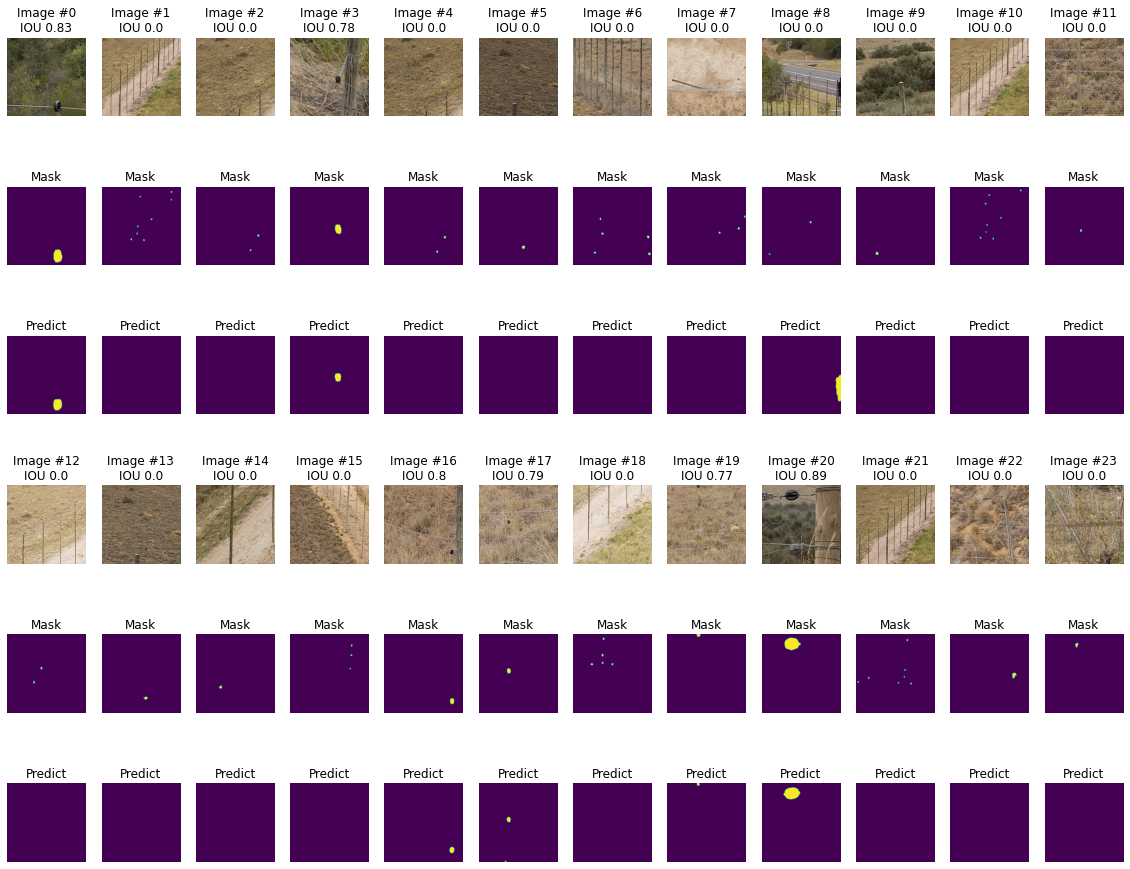

In [ ]:
#plt.figure(figsize=(20,10.5))
plt.figure(figsize=(20,16))
x, y = 12,2
for i in range(y):  
    for j in range(x):
        # train image
        plt.subplot(y*3, x, i*3*x+j+1)
        pos = i*x+j
        plt.imshow(X_val[pos])
        plt.title('Image #{}\nIOU {}'.format(pos,round(cal_iou(np.squeeze(Y_val[pos]), np.squeeze(preds_val_t[pos])),2)))
        plt.axis('off')
        plt.subplot(y*3, x, (i*3+1)*x+j+1)
        plt.imshow(np.squeeze(Y_val[pos]))
        plt.title('Mask')
        plt.axis('off')
        plt.subplot(y*3, x, (i*3+2)*x+j+1)
        plt.imshow(np.squeeze(preds_val_t[pos]))
        plt.title('Predict')
        plt.axis('off')
plt.show()

In [ ]:
# illustrate the details for some images
'''
ixs = [8,17,18]
plt.figure(figsize=(16,8))
x, y =  6, len(ixs)
for i, ix in enumerate(ixs):  
    # original
    plt.subplot(y,x, i*x+1)
    plt.imshow(X_val[ix])
    plt.title('#{} IOU: {}'.format(ix+1,round(cal_iou(np.squeeze(Y_val[ix]), np.squeeze(preds_val_t[ix])),2)))
    plt.axis('off')
    # grand true
    plt.subplot(y,x, i*x+2)
    plt.imshow(np.squeeze(Y_val[ix]))
    plt.title('Mask')
    plt.axis('off')
    # prediction
    plt.subplot(y,x, i*x+3)
    pred = preds_val_t[ix]>0
    plt.imshow(np.squeeze(pred))
    plt.title('Prediction')
    plt.axis('off')
    # true positive
    plt.subplot(y,x, i*x+4)
    fp = np.logical_and(pred, Y_val[ix])  
    plt.imshow(np.squeeze(fp))
    plt.title('True Positive')
    plt.axis('off')   
    # false positive
    plt.subplot(y,x, i*x+5)
    fp = np.logical_and(pred, np.logical_not(Y_val[ix]))  
    plt.imshow(np.squeeze(fp))
    plt.title('False Positive') 
    plt.axis('off')       
    # false negtive
    plt.subplot(y,x, i*x+6)
    fn = np.logical_and(np.logical_not(pred), Y_val[ix]) 
    plt.imshow(np.squeeze(fn))
    plt.title('False Negtive')     
    plt.axis('off')   
plt.tight_layout()
plt.show()'''

"\nixs = [8,17,18]\nplt.figure(figsize=(16,8))\nx, y =  6, len(ixs)\nfor i, ix in enumerate(ixs):  \n    # original\n    plt.subplot(y,x, i*x+1)\n    plt.imshow(X_val[ix])\n    plt.title('#{} IOU: {}'.format(ix+1,round(cal_iou(np.squeeze(Y_val[ix]), np.squeeze(preds_val_t[ix])),2)))\n    plt.axis('off')\n    # grand true\n    plt.subplot(y,x, i*x+2)\n    plt.imshow(np.squeeze(Y_val[ix]))\n    plt.title('Mask')\n    plt.axis('off')\n    # prediction\n    plt.subplot(y,x, i*x+3)\n    pred = preds_val_t[ix]>0\n    plt.imshow(np.squeeze(pred))\n    plt.title('Prediction')\n    plt.axis('off')\n    # true positive\n    plt.subplot(y,x, i*x+4)\n    fp = np.logical_and(pred, Y_val[ix])  \n    plt.imshow(np.squeeze(fp))\n    plt.title('True Positive')\n    plt.axis('off')   \n    # false positive\n    plt.subplot(y,x, i*x+5)\n    fp = np.logical_and(pred, np.logical_not(Y_val[ix]))  \n    plt.imshow(np.squeeze(fp))\n    plt.title('False Positive') \n    plt.axis('off')       \n    # false negt

In [ ]:
# Get test data
X_test = get_X_data(test_path, output_shape=(img_height,img_width))

In [ ]:
# Use model to predict test labels
Y_hat = model_loaded.predict(X_test, verbose=1)
Y_hat.shape

## Visualize predictions on the test data

In [ ]:
id = 32
print(X_test[id].shape)
skimage.io.imshow(X_test[id])
plt.show()
skimage.io.imshow(Y_hat[id][:,:,0])
plt.show()

In [ ]:
# Predict on val
preds_test = model.predict(X_test, verbose=1)
# Threshold predictions
#preds_val_t = (preds_val > 0.5).astype(np.uint8)
preds_test_t = (preds_test > 0.5)

In [ ]:
plt.figure(figsize=(20,16))
x, y = 12,2
for i in range(y):  
    for j in range(x):
      plt.subplot(y*3, x, i*3*x+j+1) 
      pos = i*x+j
      #plt.imshow(X_test[pos]) 
      plt.imshow(X_test[pos])
      plt.title('Test #{}\nIOU {}'.format(pos,round(cal_iou(np.squeeze(Y_test[pos]), np.squeeze(preds_test_t[pos])),2)))
      plt.axis('off')
      plt.subplot(y*3, x, (i*3+2)*x+j+1)
      plt.imshow(Y_hat[pos][:,:,0])
      plt.title('Detect')
      plt.axis('off')
plt.show()
        